In [1]:
#EDA
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
print(df.head(5))
print(df.info())
print(df.isnull().sum())

(200, 5)
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Genre         

In [2]:
#1 Feature Selection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')

# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)',]] 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=5, random_state=42) # Initialize KMeans with 5 clusters and a fixed random state
df['Cluster'] = kmeans.fit_predict(X_scaled) # Add cluster labels to original DataFrame
centroids = kmeans.cluster_centers_ # Get centroids in original scale
#centroids = scaler.inverse_transform(centroids) # Inverse transform to original scale

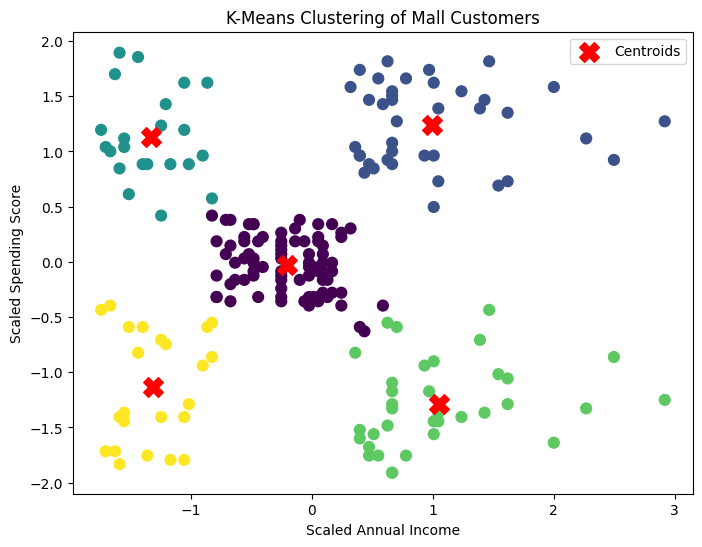

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1],c=df['Cluster'], cmap='viridis', s=60)
plt.scatter(centroids[:,0], centroids[:,1],color='red', marker='X', s=200, label='Centroids')
plt.xlabel('Scaled Annual Income')
plt.ylabel('Scaled Spending Score')
plt.title('K-Means Clustering of Mall Customers')
plt.legend()
plt.show()

In [4]:
cluster_analysis = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_analysis)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
